In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv(r'localized_energy_load_classification.csv')

In [5]:
df.head()

,timestamp,zone,month,hour,weekday,temperature_C,humidity_pct,voltage_V,global_intensity_A,global_active_power_kW,global_reactive_power_kW,power_factor,sub_metering_1_Wh,sub_metering_2_Wh,sub_metering_3_Wh,energy_consumed_kWh,demand_class
0,2024-08-07 04:00:00,Navi Mumbai,8,4,2,28.44,78.69,213.83,1.751,0.3744,0.0812,0.9773,0.10,0.45,0.22,0.0936,Low
1,2020-01-11 03:15:00,Powai,1,3,5,18.38,48.83,224.09,3.131,0.7016,0.0799,0.9936,3.05,0.37,0.96,0.1754,Low
2,2020-01-05 13:15:00,Navi Mumbai,1,13,6,21.76,49.94,222.68,9.517,2.1193,0.7389,0.9443,4.31,0.34,4.27,0.5298,High
3,2020-11-21 22:15:00,Colaba,11,22,5,20.44,68.19,217.11,2.933,0.6367,0.0907,0.9900,0.30,0.33,1.42,0.1592,Low
4,2024-12-28 23:00:00,Thane,12,23,5,19.14,64.21,226.76,3.223,0.7309,0.1676,0.9747,1.06,0.07,1.49,0.1827,Low


In [6]:
df.tail()

,timestamp,zone,month,hour,weekday,temperature_C,humidity_pct,voltage_V,global_intensity_A,global_active_power_kW,global_reactive_power_kW,power_factor,sub_metering_1_Wh,sub_metering_2_Wh,sub_metering_3_Wh,energy_consumed_kWh,demand_class
221095,2022-06-02 17:45:00,Navi Mumbai,6,17,3,28.87,61.30,214.27,10.381,2.2243,0.5430,0.9715,6.75,2.20,1.04,0.5561,High
221096,2021-12-16 03:30:00,Kurla,12,3,3,15.06,60.49,218.22,2.593,0.5658,0.1955,0.9452,0.18,0.67,0.14,0.1415,Low
221097,2022-10-06 07:00:00,Borivali,10,7,3,19.31,81.98,228.66,6.790,1.5527,0.3185,0.9796,0.70,0.70,0.17,0.3882,Medium
221098,2023-03-10 20:45:00,Kurla,3,20,4,24.55,30.00,205.84,8.462,1.7419,0.5676,0.9508,0.42,0.51,5.20,0.4355,Medium
221099,2022-06-24 09:30:00,Andheri,6,9,4,34.72,56.51,223.95,23.173,5.1894,0.8537,0.9867,7.42,1.22,15.47,1.2974,High


In [7]:
df.shape

(221100, 17)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221100 entries, 0 to 221099
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 221100 non-null  object 
 1   zone                      221100 non-null  object 
 2   month                     221100 non-null  int64  
 3   hour                      221100 non-null  int64  
 4   weekday                   221100 non-null  int64  
 5   temperature_C             219033 non-null  float64
 6   humidity_pct              219097 non-null  float64
 7   voltage_V                 221100 non-null  float64
 8   global_intensity_A        221100 non-null  float64
 9   global_active_power_kW    221100 non-null  float64
 10  global_reactive_power_kW  219117 non-null  float64
 11  power_factor              221100 non-null  float64
 12  sub_metering_1_Wh         219066 non-null  float64
 13  sub_metering_2_Wh         221100 non-null  f

In [9]:
df.describe()

,month,hour,weekday,temperature_C,humidity_pct,voltage_V,global_intensity_A,global_active_power_kW,global_reactive_power_kW,power_factor,sub_metering_1_Wh,sub_metering_2_Wh,sub_metering_3_Wh,energy_consumed_kWh
count,221100.000000,221100.000000,221100.000000,219033.000000,219097.000000,221100.000000,221100.000000,221100.000000,219117.000000,221100.000000,219066.000000,221100.000000,221100.000000,221100.000000
mean,6.333813,11.499444,2.998453,24.915364,59.397270,219.986872,8.390173,1.843067,0.414457,0.973552,3.068241,1.379433,2.103496,0.460767
std,3.493030,6.922305,1.999294,4.657266,15.053818,7.975422,5.912605,1.296254,0.333460,0.015009,4.265685,1.942041,2.939482,0.324063
min,1.000000,0.000000,0.000000,15.000000,30.000000,195.000000,0.500000,0.100000,0.010000,0.943900,0.000000,0.000000,0.000000,0.025000
25%,3.000000,5.000000,1.000000,21.000000,46.090000,214.590000,3.743000,0.823200,0.167500,0.961100,0.530000,0.240000,0.360000,0.205800
50%,6.000000,11.000000,3.000000,24.840000,58.830000,220.010000,6.842000,1.504800,0.317600,0.975600,1.540000,0.690000,1.060000,0.376200
75%,9.000000,18.000000,5.000000,28.820000,72.870000,225.380000,11.965000,2.631400,0.567200,0.987000,3.800000,1.700000,2.620000,0.657825
max,12.000000,23.000000,6.000000,38.550000,98.000000,245.000000,35.316000,7.350900,2.411100,0.995000,35.000000,25.000000,30.000000,1.837700


In [10]:
df.duplicated().sum()

np.int64(1100)

In [11]:
df.drop_duplicates(keep='first', inplace=True)

In [12]:
df.isna().sum()

timestamp                      0
zone                           0
month                          0
hour                           0
weekday                        0
temperature_C               2059
humidity_pct                1994
voltage_V                      0
global_intensity_A             0
global_active_power_kW         0
global_reactive_power_kW    1972
power_factor                   0
sub_metering_1_Wh           2023
sub_metering_2_Wh              0
sub_metering_3_Wh              0
energy_consumed_kWh            0
demand_class                   0
dtype: int64

In [13]:
for col in df.select_dtypes('float64','int64').columns:
    df[col] = df[col].fillna(df[col].median())

In [14]:
df.isna().sum()

timestamp                   0
zone                        0
month                       0
hour                        0
weekday                     0
temperature_C               0
humidity_pct                0
voltage_V                   0
global_intensity_A          0
global_active_power_kW      0
global_reactive_power_kW    0
power_factor                0
sub_metering_1_Wh           0
sub_metering_2_Wh           0
sub_metering_3_Wh           0
energy_consumed_kWh         0
demand_class                0
dtype: int64

In [15]:
df.shape

(220000, 17)

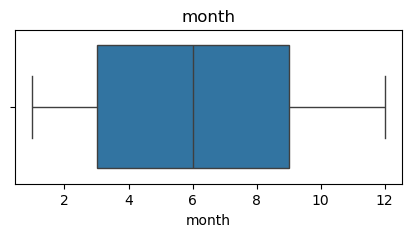

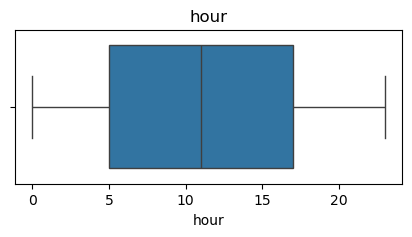

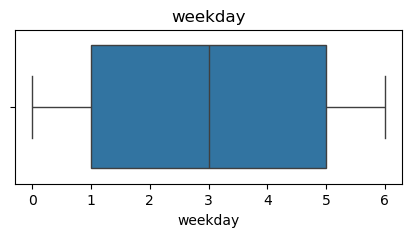

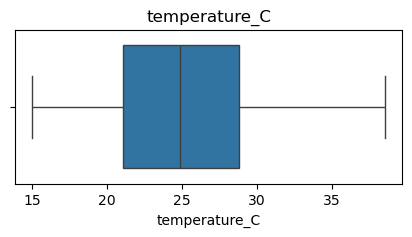

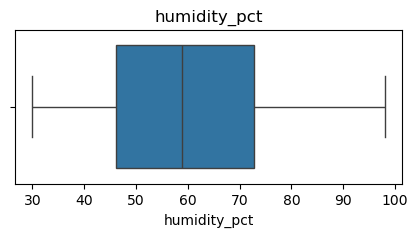

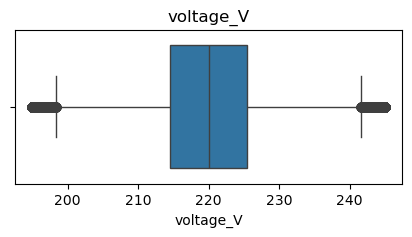

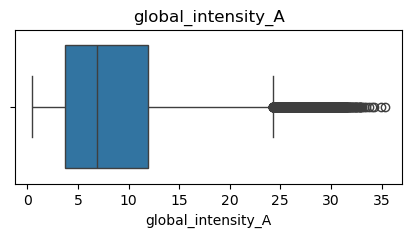

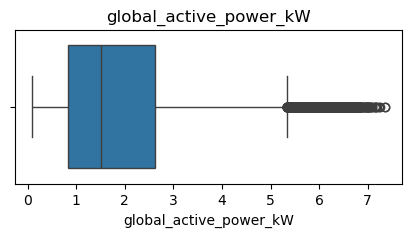

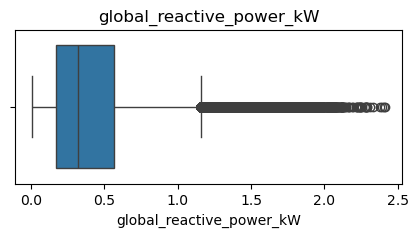

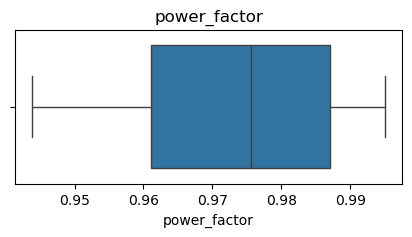

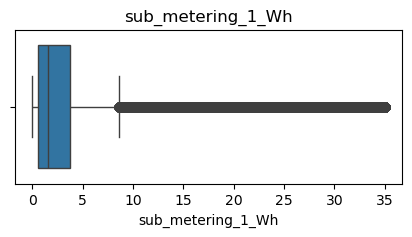

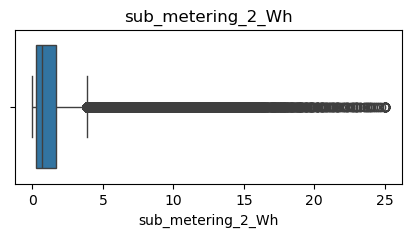

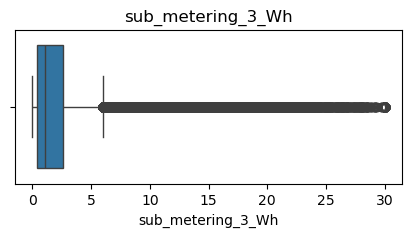

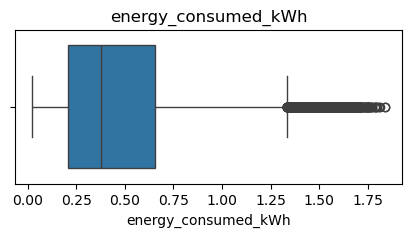

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Text(0.5, 1.0, 'Distribution of Demand Class (Target)')

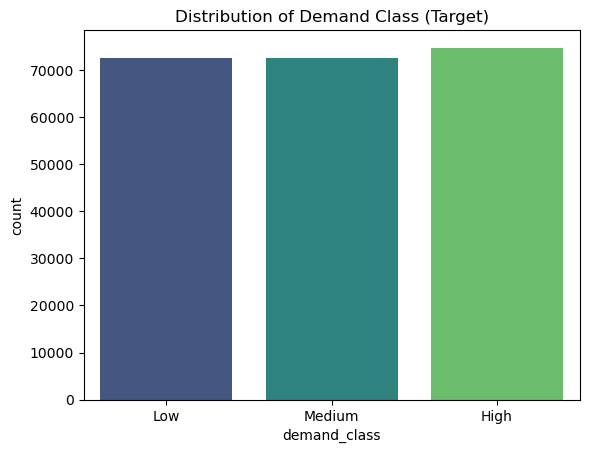

In [17]:
# Target Variable Distribution

plt.figure()
sns.countplot(x='demand_class', data=df, order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Distribution of Demand Class (Target)')

Text(0.5, 1.0, 'Temperature Distribution profile')

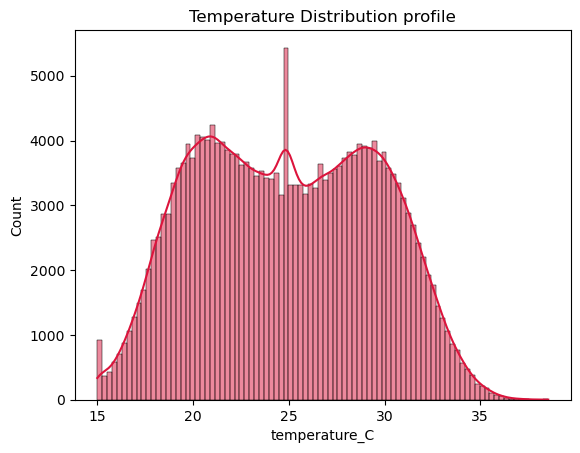

In [18]:
# Temperature Distribution

plt.figure()
sns.histplot(df['temperature_C'], kde=True, color='crimson')
plt.title('Temperature Distribution profile')

Text(0.5, 1.0, 'Humidity Distribution profile')

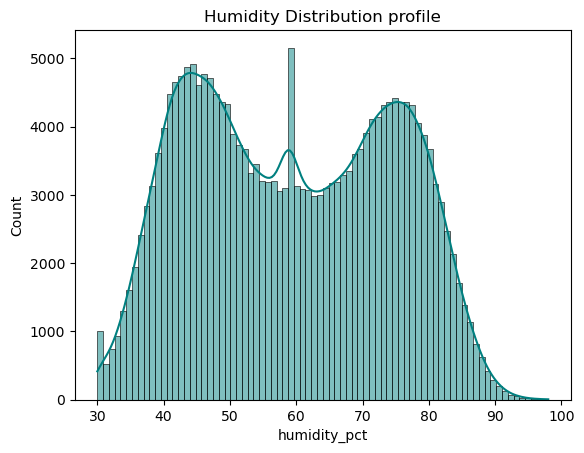

In [19]:
# Humidity Distribution

plt.figure()
sns.histplot(df['humidity_pct'], kde=True, color='teal')
plt.title('Humidity Distribution profile')

Text(0.5, 1.0, 'Voltage Breakdown by Demand Class')

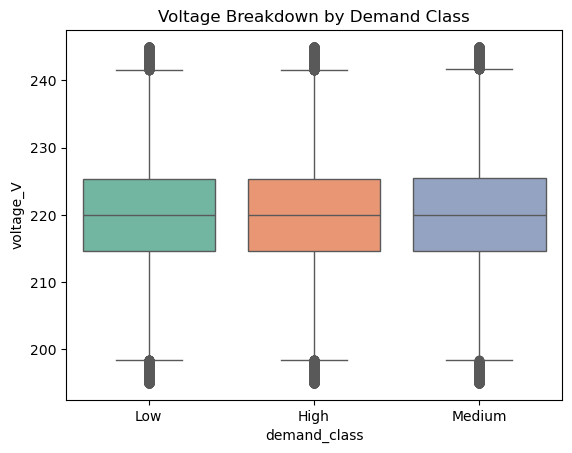

In [20]:
# Voltage Distribution

plt.figure()
sns.boxplot(x='demand_class', y='voltage_V', data=df, palette='Set2')
plt.title('Voltage Breakdown by Demand Class')

Text(0.5, 1.0, 'Active Power vs Total Energy Consumed')

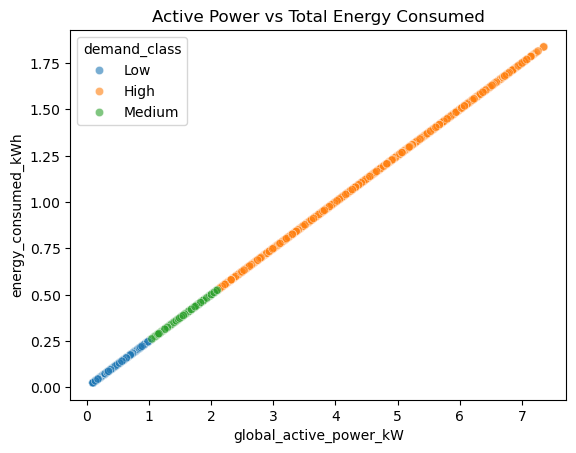

In [21]:
# Global Active Power vs. Energy Consumed

plt.figure()
sns.scatterplot(x='global_active_power_kW', y='energy_consumed_kWh', hue='demand_class', data=df, alpha=0.6)
plt.title('Active Power vs Total Energy Consumed')

Text(0.5, 1.0, 'Demand Classification across Mumbai Zones')

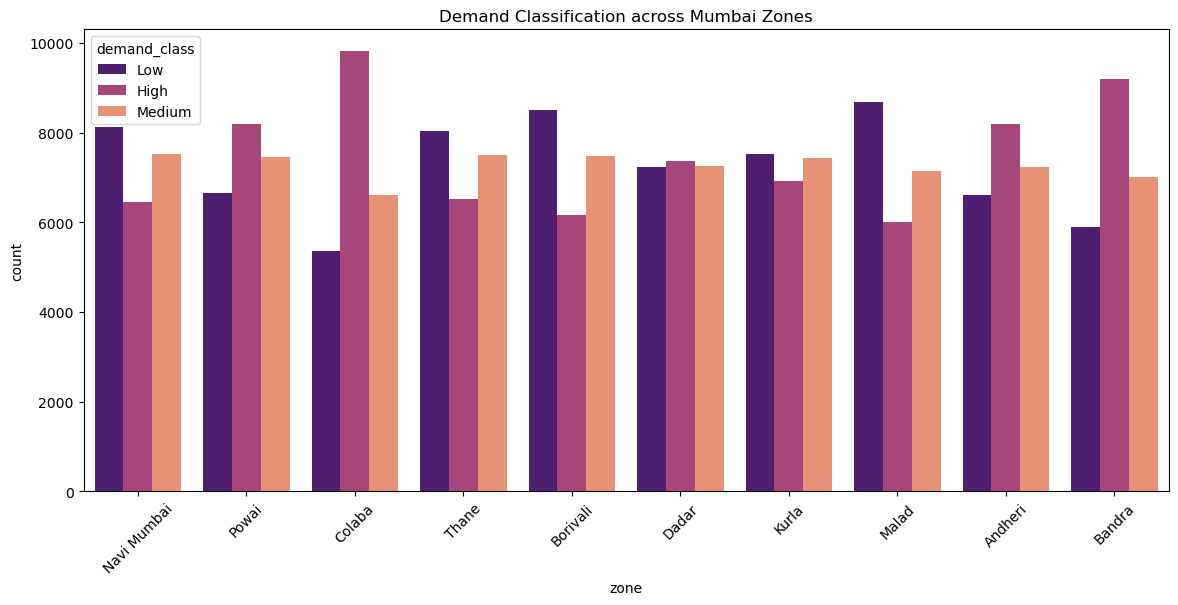

In [22]:
# Regional Analysis - Demand across different Zones

plt.figure(figsize=(14, 6))
sns.countplot(x='zone', hue='demand_class', data=df, palette='magma')
plt.xticks(rotation=45)
plt.title('Demand Classification across Mumbai Zones')

Text(0.5, 1.0, 'Hourly Energy Consumption Profile')

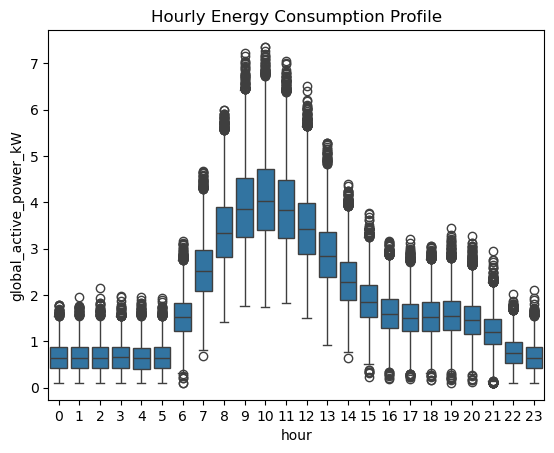

In [23]:
# Hourly Demand Trends

plt.figure()
sns.boxplot(x='hour', y='global_active_power_kW', data=df)
plt.title('Hourly Energy Consumption Profile')

Text(0.5, 1.0, 'Monthly Average Active Power Load')

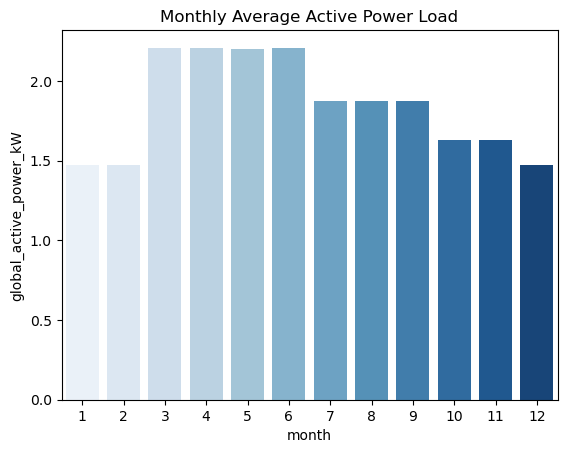

In [24]:
# Monthly Demand Trends

plt.figure()
sns.barplot(x='month', y='global_active_power_kW', data=df, errorbar=None, palette='Blues')
plt.title('Monthly Average Active Power Load')

Text(0.5, 1.0, 'Energy Consumption Profile by Day of Week')

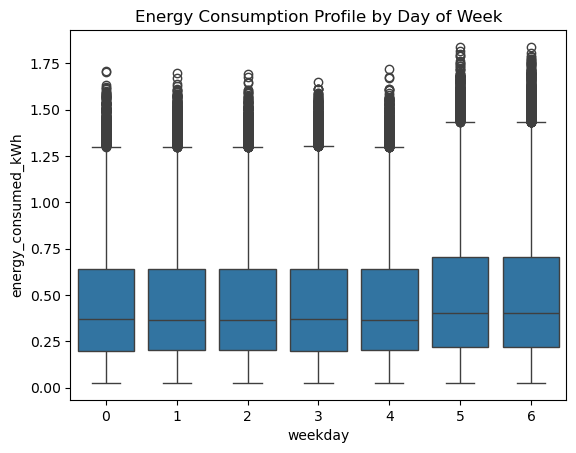

In [25]:
# Weekday vs Weekend load profile

plt.figure()
sns.boxplot(x='weekday', y='energy_consumed_kWh', data=df)
plt.title('Energy Consumption Profile by Day of Week')

Text(0.5, 1.0, 'Weather Matrix (Temp vs Humidity)')

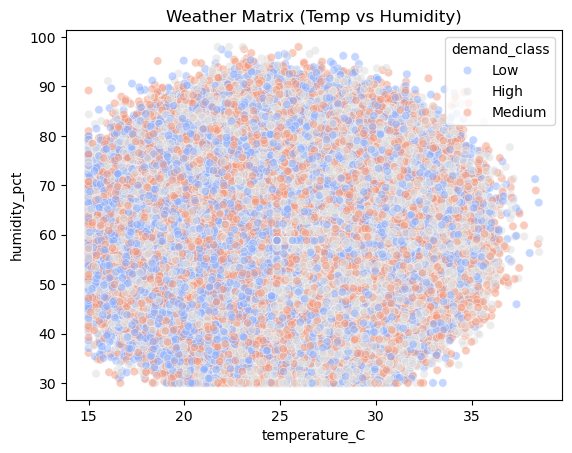

In [26]:
# Temperature vs Humidity colored by Demand Class

plt.figure()
sns.scatterplot(x='temperature_C', y='humidity_pct', hue='demand_class', data=df, palette='coolwarm', alpha=0.5)
plt.title('Weather Matrix (Temp vs Humidity)')

Text(0.5, 1.0, 'Sub Metering 1 Distribution per Demand Class')

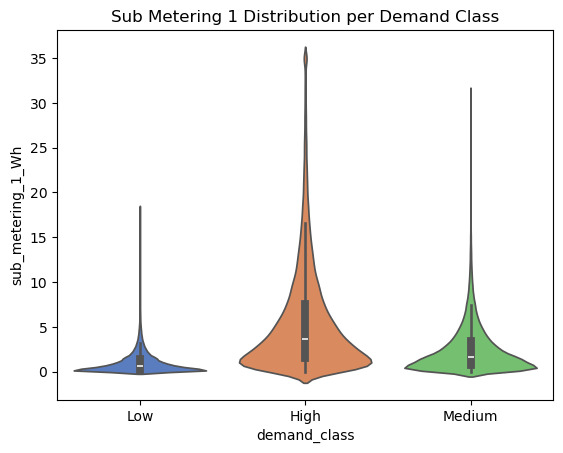

In [27]:
# Sub Metering 1 vs Demand Class

plt.figure()
sns.violinplot(x='demand_class', y='sub_metering_1_Wh', data=df, palette='muted')
plt.title('Sub Metering 1 Distribution per Demand Class')

Text(0.5, 1.0, 'Sub Metering 2 Distribution per Demand Class')

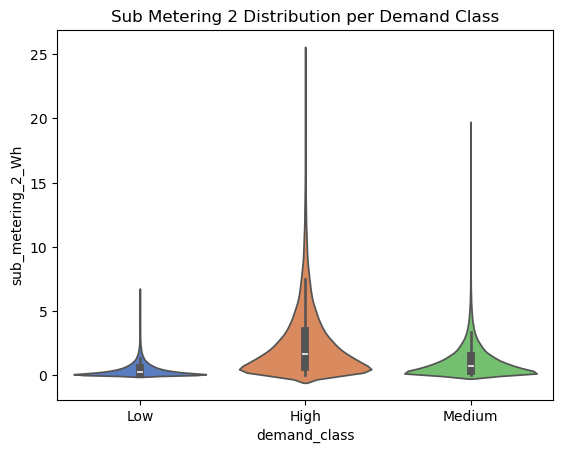

In [28]:
# Sub Metering 2 vs Demand Class

plt.figure()
sns.violinplot(x='demand_class', y='sub_metering_2_Wh', data=df, palette='muted')
plt.title('Sub Metering 2 Distribution per Demand Class')

Text(0.5, 1.0, 'Sub Metering 3 Distribution per Demand Class')

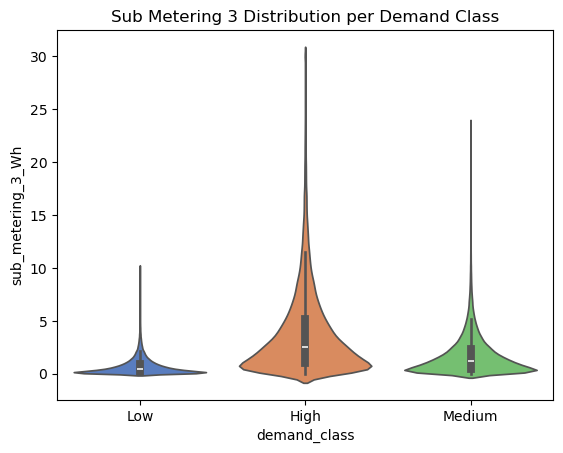

In [29]:
# Sub Metering 3 vs Demand Class

plt.figure()
sns.violinplot(x='demand_class', y='sub_metering_3_Wh', data=df, palette='muted')
plt.title('Sub Metering 3 Distribution per Demand Class')

Text(0.5, 1.0, 'Power Factor Density across Classes')

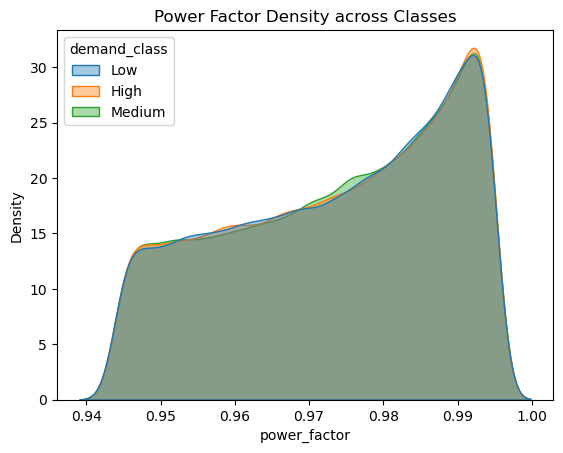

In [30]:
# Power Factor vs Demand Class

plt.figure()
sns.kdeplot(data=df, x='power_factor', hue='demand_class', fill=True, common_norm=False, alpha=0.4)
plt.title('Power Factor Density across Classes')

Text(0.5, 1.0, ' Linear relationship between Intensity and Active Power')

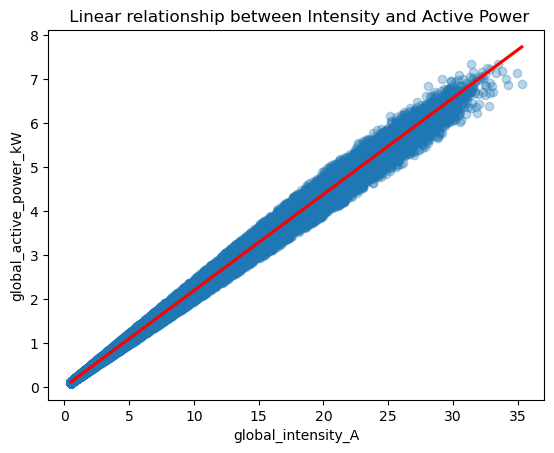

In [31]:
# Global Intensity vs Active Power

plt.figure()
sns.regplot(x='global_intensity_A', y='global_active_power_kW', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(' Linear relationship between Intensity and Active Power')

Text(0.5, 1.0, 'Multicollinearity & Correlation Matrix')

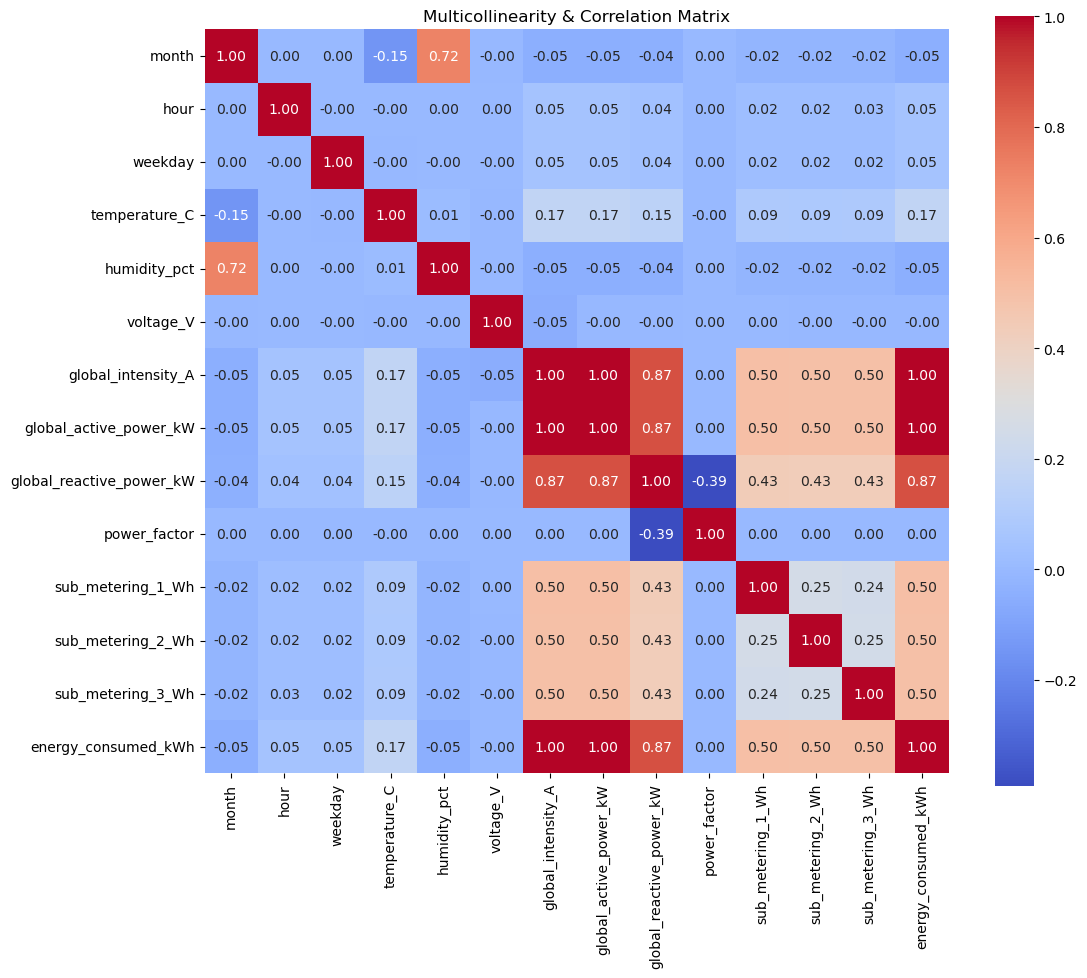

In [32]:
# Correlation Heatmap of Numerical features

plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Multicollinearity & Correlation Matrix')

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score 
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [34]:
# Sample 1,00,000 rows for efficient KNN execution

df = df.sample(n=10000, random_state=42).reset_index(drop=True)

In [35]:
cat_cols = df.select_dtypes(include='object')

label = LabelEncoder()
for c in cat_cols:
    df[c] = label.fit_transform(df[c])

In [36]:
x = df.drop(columns=['timestamp', 'demand_class'], axis=1)
y = df['demand_class']

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [38]:
#
scaler = StandardScaler()

# Fit only on the training set and transform both sets
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [39]:
K = range(1, 20, 2)

for i in K:
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"K neighbor : {i}")
    print(f"Accuracy Score : {acc}" )
    print(f"Classification Report : \n{class_report}" )

K neighbor : 1
Accuracy Score : 0.8655
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       652
           1       0.85      0.91      0.88       661
           2       0.82      0.78      0.80       687

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

K neighbor : 3
Accuracy Score : 0.892
Classification Report : 
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       652
           1       0.87      0.94      0.90       661
           2       0.86      0.82      0.84       687

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

K neighbor : 5
Accuracy Score : 0.8985
Classification Report : 
              precision    recall  f1-score   s

Text(0.5, 1.0, 'Model Residuals Error Distribution')

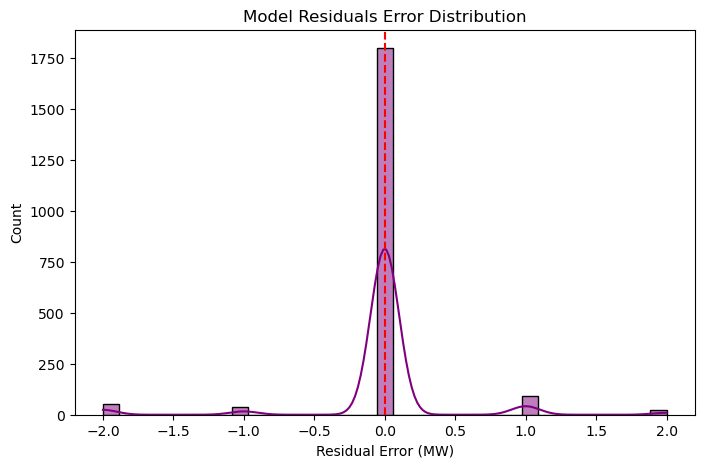

In [41]:
# Residuals Distribution

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=35)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual Error (MW)')
plt.title("Model Residuals Error Distribution")

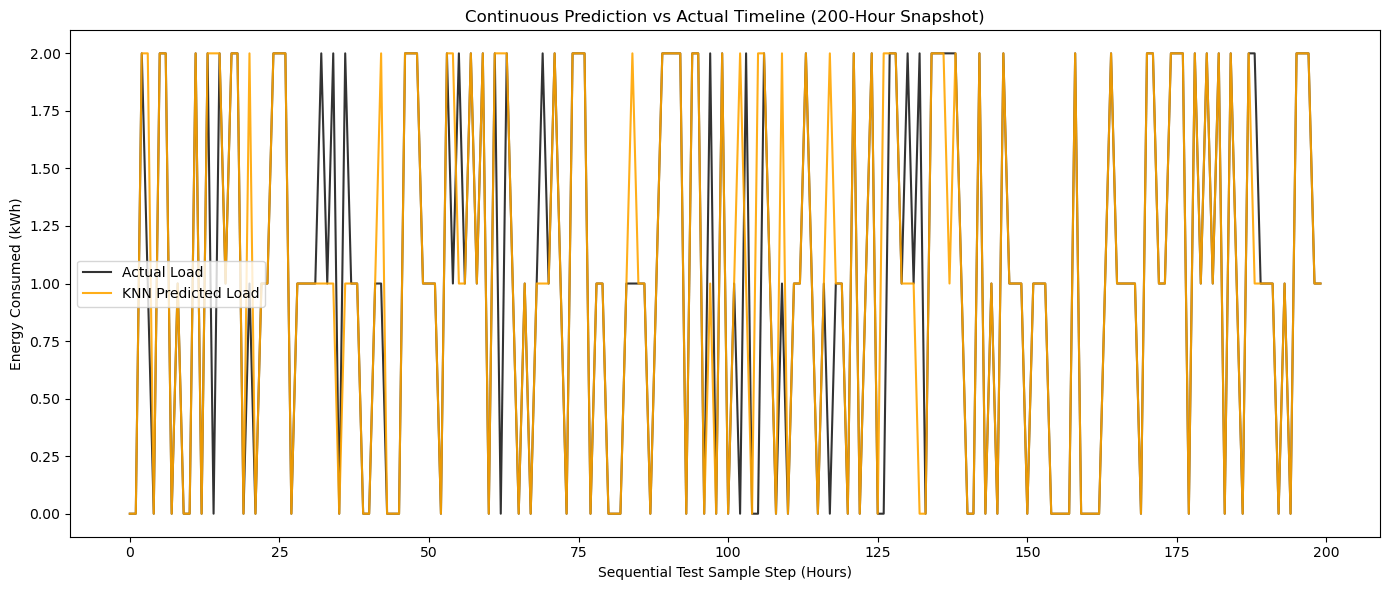

In [42]:
# Timeline view of Predictions vs Actual (Sampled window for clarity)

plt.figure(figsize=(14, 6))
eval_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).iloc[:200]  # First 200 hours
plt.plot(eval_df['Actual'].values, label='Actual Load', color='black', alpha=0.8, lw=1.5)
plt.plot(eval_df['Predicted'].values, label='KNN Predicted Load', color='orange', alpha=0.9, lw=1.5)
plt.ylabel('Energy Consumed (kWh)')
plt.xlabel('Sequential Test Sample Step (Hours)')
plt.title("Continuous Prediction vs Actual Timeline (200-Hour Snapshot)")
plt.legend()
plt.tight_layout()